# Week05-06 HW03: Tree Ensemble to Boosting

Kaggle Titanic 데이터셋에서 Random Forest, XGBoost, LightGBM을 동일한 validation 구조로 비교합니다.

- **Dataset**: Kaggle Titanic competition `train.csv`
- **Data path**: `data/raw/titanic/train.csv` (DVC로 관리)
- **Problem type**: Binary Classification
- **Target**: `Survived`
- **Metrics**: Accuracy, F1, ROC-AUC
- **Tuning**: XGBoost & LightGBM 핵심 하이퍼파라미터 조정
- **Early Stopping**: XGBoost & LightGBM 모두 적용


## 0. Environment

필요한 라이브러리가 없다면 아래 주석을 해제해서 설치합니다.

```python
# %pip install pandas numpy scikit-learn xgboost lightgbm matplotlib optuna
```

In [118]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
TARGET = "Survived"

## 1. Data Preparation

Titanic 데이터는 빠진 정보를 상식적으로 채워서 생존 여부를 예측하는 전형적인 분류 문제입니다.
Kaggle의 `test.csv`에는 정답인 `Survived`가 없으므로, 여기서는 `train.csv`를 train/validation/test로 직접 분할해서 모든 평가를 진행합니다.

In [119]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "titanic" / "train.csv").exists():
            return path
    raise FileNotFoundError(
        "data/raw/titanic/train.csv 파일을 찾지 못했습니다. 필요하면 `dvc pull`로 데이터를 다운로드하세요."
    )


project_root = find_project_root()
data_dir = project_root / "data" / "raw" / "titanic"
train_path = data_dir / "train.csv"

df = pd.read_csv(train_path)

print(f"Train data path : {train_path.resolve()}")
print(f"Shape           : {df.shape}")
display(df.head())

Train data path : C:\Users\tree0\OneDrive\바탕 화면\행복한 석사생활\수업\AI융합실전프로젝트3\MLOps-Project\data\raw\titanic\train.csv
Shape           : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. EDA

모델 훈련 전에 target 분포, 범주형 변수별 생존율, 주요 결측치의 현황을 확인합니다.

In [120]:
display(df[TARGET].value_counts().rename("count"))
display(df[TARGET].value_counts(normalize=True).rename("ratio"))

eda_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_ratio": df.isna().mean(),
        "n_unique": df.nunique(),
    }
).sort_values("missing_ratio", ascending=False)

display(eda_summary)

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    0.616162
1    0.383838
Name: ratio, dtype: float64

,dtype,missing_count,missing_ratio,n_unique
Cabin,object,687,0.771044,147
Age,float64,177,0.198653,88
Embarked,object,2,0.002245,3
PassengerId,int64,0,0.000000,891
Survived,int64,0,0.000000,2
Pclass,int64,0,0.000000,3
Name,object,0,0.000000,891
Sex,object,0,0.000000,2
SibSp,int64,0,0.000000,7
Parch,int64,0,0.000000,7


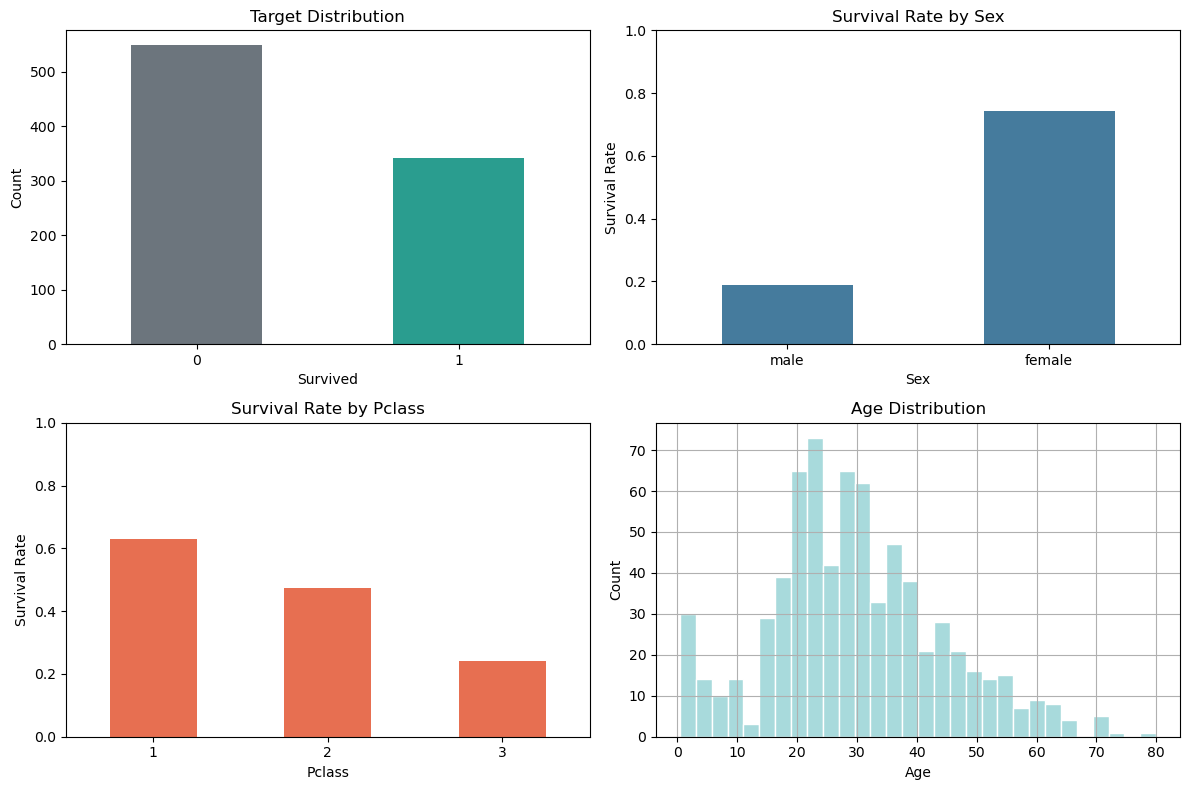

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df[TARGET].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color=["#6C757D", "#2A9D8F"])
axes[0, 0].set_title("Target Distribution")
axes[0, 0].set_xlabel("Survived")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xticklabels(["0", "1"], rotation=0)

df.groupby("Sex")[TARGET].mean().sort_values().plot(kind="bar", ax=axes[0, 1], color="#457B9D")
axes[0, 1].set_title("Survival Rate by Sex")
axes[0, 1].set_xlabel("Sex")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=0)

df.groupby("Pclass")[TARGET].mean().sort_index().plot(kind="bar", ax=axes[1, 0], color="#E76F51")
axes[1, 0].set_title("Survival Rate by Pclass")
axes[1, 0].set_xlabel("Pclass")
axes[1, 0].set_ylabel("Survival Rate")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis="x", rotation=0)

df["Age"].hist(bins=30, ax=axes[1, 1], color="#A8DADC", edgecolor="white")
axes[1, 1].set_title("Age Distribution")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [122]:
group_summary = pd.concat(
    [
        df.groupby("Sex")[TARGET].agg(["count", "mean"]).assign(feature="Sex"),
        df.groupby("Pclass")[TARGET].agg(["count", "mean"]).assign(feature="Pclass"),
        df.groupby("Embarked")[TARGET].agg(["count", "mean"]).assign(feature="Embarked"),
    ]
).rename(columns={"mean": "survival_rate"})

display(group_summary.round(4))

numeric_corr = df[["Survived", "Age", "Fare", "SibSp", "Parch"]].corr(numeric_only=True)["Survived"]
display(numeric_corr.sort_values(ascending=False).rename("correlation_with_survived").round(4))

,count,survival_rate,feature
female,314,0.7420,Sex
male,577,0.1889,Sex
1,216,0.6296,Pclass
2,184,0.4728,Pclass
3,491,0.2424,Pclass
C,168,0.5536,Embarked
Q,77,0.3896,Embarked
S,644,0.3370,Embarked


Survived    1.0000
Fare        0.2573
Parch       0.0816
SibSp      -0.0353
Age        -0.0772
Name: correlation_with_survived, dtype: float64

## 3. Preprocessing

특정 feature engineering보다 **Random Forest vs Boosting 모델 차이** 자체에 집중하기 위해 전처리를 최소한으로 유지합니다.

| 구분 | 피처 | 처리 방법 |
|---|---|---|
| Numeric | `Age`, `Fare`, `SibSp`, `Parch` | Median Imputation |
| Categorical | `Sex`, `Embarked`, `Pclass` | Most Frequent Imputation → One-Hot Encoding |


In [123]:
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
categorical_features = ["Sex", "Embarked", "Pclass"]

X = df[numeric_features + categorical_features].copy()
y = df[TARGET].copy()

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)
display(X.head())

Numeric features    : ['Age', 'Fare', 'SibSp', 'Parch']
Categorical features: ['Sex', 'Embarked', 'Pclass']


,Age,Fare,SibSp,Parch,Sex,Embarked,Pclass
0,22.0,7.2500,1,0,male,S,3
1,38.0,71.2833,1,0,female,C,1
2,26.0,7.9250,0,0,female,S,3
3,35.0,53.1000,1,0,female,S,1
4,35.0,8.0500,0,0,male,S,3


### Train / Validation / Test Split

전체 데이터를 **60% train / 20% validation / 20% test** 로 분할합니다.
생존/사망 비율 유지를 위해 stratified split을 사용합니다.

In [124]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}  |  target ratio: {y_train.mean():.3f}")
print(f"Valid : {X_valid.shape}  |  target ratio: {y_valid.mean():.3f}")
print(f"Test  : {X_test.shape}  |  target ratio: {y_test.mean():.3f}")

Train : (534, 7)  |  target ratio: 0.384
Valid : (178, 7)  |  target ratio: 0.382
Test  : (179, 7)  |  target ratio: 0.385


In [125]:
try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", categorical_encoder),
            ]),
            categorical_features,
        ),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_valid_prep = preprocessor.transform(X_valid)
X_test_prep  = preprocessor.transform(X_test)

print("Preprocessed train shape:", X_train_prep.shape)

Preprocessed train shape: (534, 12)


## 4. Evaluation Function

In [126]:
def evaluate_classifier(model, X_eval, y_eval, dataset_name: str, model_name: str) -> dict:
    pred  = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]
    return {
        "model"   : model_name,
        "dataset" : dataset_name,
        "accuracy": accuracy_score(y_eval, pred),
        "f1"      : f1_score(y_eval, pred),
        "roc_auc" : roc_auc_score(y_eval, proba),
    }


results = []

## 5. Baseline Model Comparison

세 모델을 동일한 train/validation/test 구조에서 기본 파라미터로 먼저 비교합니다.
이 단계의 목적은 **튜닝 전 베이스라인 성능**을 파악하는 것입니다.

### 5-1. Random Forest (Bagging)

Random Forest는 독립적으로 학습한 여러 Decision Tree의 예측을 **다수결(bagging)** 로 합칩니다.
각 트리는 데이터의 일부(bootstrap sample)와 피처의 일부만 보기 때문에 개별 트리는 약하지만,
서로 다른 오류를 범해 앙상블하면 분산이 낮아집니다.

In [127]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_prep, y_train)

for split_name, X_s, y_s in [("train", X_train_prep, y_train),
                              ("validation", X_valid_prep, y_valid),
                              ("test", X_test_prep, y_test)]:
    results.append(evaluate_classifier(rf_model, X_s, y_s, split_name, "RandomForest"))

print("RandomForest 학습 완료")

RandomForest 학습 완료


### 5-2. XGBoost (Boosting — baseline)

XGBoost는 이전 트리의 **잔차(residual)** 를 다음 트리가 보완하는 boosting 방식입니다.
트리를 순차적으로 쌓기 때문에 bias가 낮지만, 과적합 위험이 있어 Early Stopping이 중요합니다.

베이스라인에서는 Early Stopping 없이 고정 `n_estimators`로 학습합니다.

In [128]:
xgb_baseline = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_baseline.fit(X_train_prep, y_train)

for split_name, X_s, y_s in [("train", X_train_prep, y_train),
                              ("validation", X_valid_prep, y_valid),
                              ("test", X_test_prep, y_test)]:
    results.append(evaluate_classifier(xgb_baseline, X_s, y_s, split_name, "XGBoost baseline"))

print("XGBoost baseline 학습 완료")

XGBoost baseline 학습 완료


### 5-3. LightGBM (Boosting — baseline)

LightGBM은 XGBoost와 같은 gradient boosting 계열이지만,
**leaf-wise tree growth** 방식으로 더 빠르고 메모리 효율이 좋습니다.
`num_leaves`가 핵심 파라미터로, depth-wise 방식의 `max_depth`에 비해 더 세밀한 모델을 만들 수 있습니다.

In [129]:
lgbm_baseline = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgbm_baseline.fit(X_train_prep, y_train)

for split_name, X_s, y_s in [("train", X_train_prep, y_train),
                              ("validation", X_valid_prep, y_valid),
                              ("test", X_test_prep, y_test)]:
    results.append(evaluate_classifier(lgbm_baseline, X_s, y_s, split_name, "LightGBM baseline"))

print("LightGBM baseline 학습 완료")

LightGBM baseline 학습 완료


### 5-4. Baseline 비교표

In [130]:
baseline_df = pd.DataFrame(results)
baseline_models = ["RandomForest", "XGBoost baseline", "LightGBM baseline"]
display(
    baseline_df[baseline_df["model"].isin(baseline_models)]
    .pivot(index="model", columns="dataset", values=["accuracy", "f1", "roc_auc"])
    .round(4)
)

accuracy                         f1                     \
dataset               test   train validation    test   train validation   
model                                                                      
LightGBM baseline   0.8101  0.9625     0.8315  0.7424  0.9500     0.7727   
RandomForest        0.8045  0.9045     0.8258  0.7244  0.8661     0.7634   
XGBoost baseline    0.7989  0.9064     0.8539  0.7188  0.8705     0.8030   

                  roc_auc                     
dataset              test   train validation  
model                                         
LightGBM baseline  0.8333  0.9950     0.8830  
RandomForest       0.8225  0.9790     0.8855  
XGBoost baseline   0.8101  0.9617     0.8988

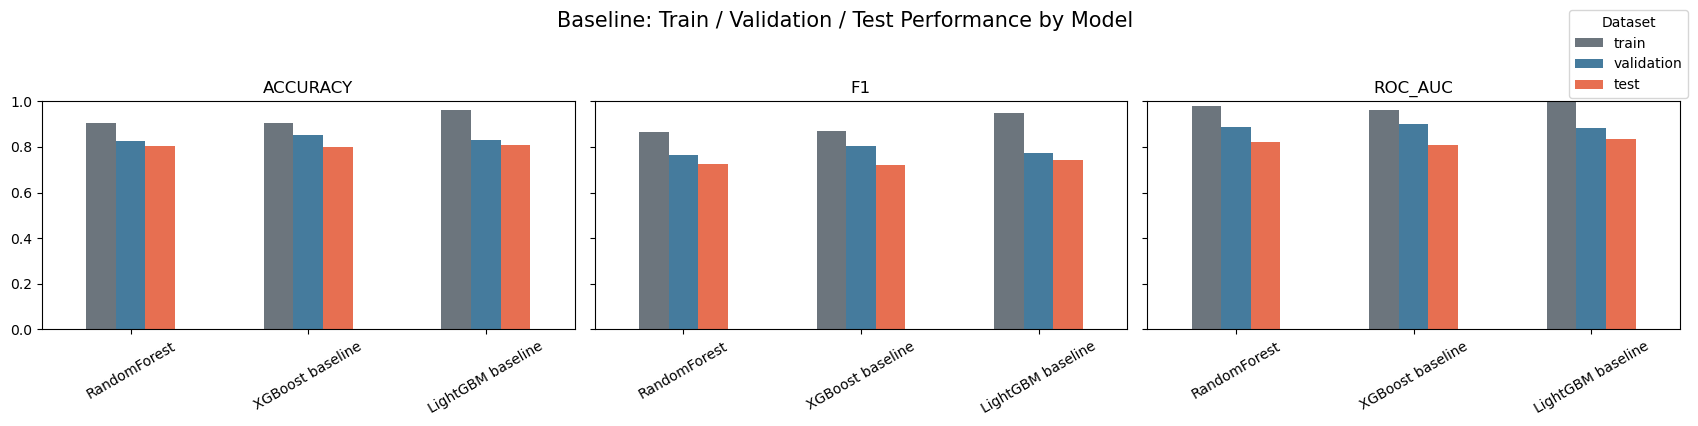

In [131]:
baseline_plot_df = baseline_df[baseline_df["model"].isin(baseline_models)].copy()
metrics = ["accuracy", "f1", "roc_auc"]
dataset_order = ["train", "validation", "test"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)

for ax, metric in zip(axes, metrics):
    pivot_df = baseline_plot_df.pivot(index="model", columns="dataset", values=metric).loc[
        baseline_models, dataset_order
    ]
    pivot_df.plot(kind="bar", ax=ax, color=["#6C757D", "#457B9D", "#E76F51"])
    ax.set_title(metric.upper())
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()  # 각 subplot legend 제거

# fig 전체에 legend 하나만 우측 상단에 표시
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Dataset", loc="upper right", bbox_to_anchor=(1, 1.07))

plt.suptitle("Baseline: Train / Validation / Test Performance by Model", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning + Early Stopping

### 튜닝 전략
- **XGBoost**: `learning_rate`, `max_depth`, `subsample` 3가지 파라미터를 grid 방식으로 탐색 + Early Stopping
- **LightGBM**: `learning_rate`, `num_leaves`, `max_depth` 3가지 파라미터를 grid 방식으로 탐색 + Early Stopping
- **Early Stopping 공통 설정**: `n_estimators=1000`, `stopping_rounds=30`, 평가 기준 `ROC-AUC (auc)`

> **왜 validation set 기반으로 튜닝하나?**  
> Boosting 계열은 train 성능이 트리 수가 많아질수록 계속 높아지지만 validation/test 성능은 어느 지점 이후 오히려 떨어집니다(과적합).  
> Early Stopping은 validation 성능이 개선되지 않으면 조기 종료함으로써 최적 iteration을 자동으로 찾아줍니다.

### 6-1. XGBoost Tuning + Early Stopping

In [132]:
xgb_param_grid = [
    {"learning_rate": 0.03, "max_depth": 3, "subsample": 0.8},
    {"learning_rate": 0.03, "max_depth": 5, "subsample": 0.8},
    {"learning_rate": 0.05, "max_depth": 3, "subsample": 0.8},
    {"learning_rate": 0.05, "max_depth": 5, "subsample": 0.8},
    {"learning_rate": 0.10, "max_depth": 3, "subsample": 0.8},
    {"learning_rate": 0.10, "max_depth": 5, "subsample": 0.8},
]

xgb_tuning_rows = []
best_xgb = None
best_xgb_score = -np.inf

for params in xgb_param_grid:
    model = XGBClassifier(
        n_estimators=1000,
        colsample_bytree=0.8,
        eval_metric="auc",
        early_stopping_rounds=30,
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **params,
    )
    model.fit(
        X_train_prep, y_train,
        eval_set=[(X_valid_prep, y_valid)],
        verbose=False,
    )
    valid_result = evaluate_classifier(model, X_valid_prep, y_valid, "validation", "XGBoost tuned")
    row = {
        **params,
        "best_iteration": model.best_iteration,
        "valid_accuracy": valid_result["accuracy"],
        "valid_f1"      : valid_result["f1"],
        "valid_roc_auc" : valid_result["roc_auc"],
    }
    xgb_tuning_rows.append(row)

    if valid_result["roc_auc"] > best_xgb_score:
        best_xgb_score = valid_result["roc_auc"]
        best_xgb = model

xgb_tuning_df = pd.DataFrame(xgb_tuning_rows).sort_values("valid_roc_auc", ascending=False)
display(xgb_tuning_df.round(4))
print(f"\n최적 XGBoost 파라미터 : {best_xgb.get_params()}")
print(f"Best iteration (early stopping): {best_xgb.best_iteration}")

,learning_rate,max_depth,subsample,best_iteration,valid_accuracy,valid_f1,valid_roc_auc
2,0.05,3,0.8,132,0.8315,0.7727,0.9029
0,0.03,3,0.8,142,0.8371,0.7680,0.9003
3,0.05,5,0.8,103,0.8483,0.7970,0.8995
5,0.10,5,0.8,37,0.8258,0.7634,0.8977
4,0.10,3,0.8,4,0.8258,0.7257,0.8941
1,0.03,5,0.8,39,0.8315,0.7581,0.8902



최적 XGBoost 파라미터 : {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': 30, 'enable_categorical': False, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1000, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0, 'use_label_encoder': False}
Best iteration (early stopping): 132


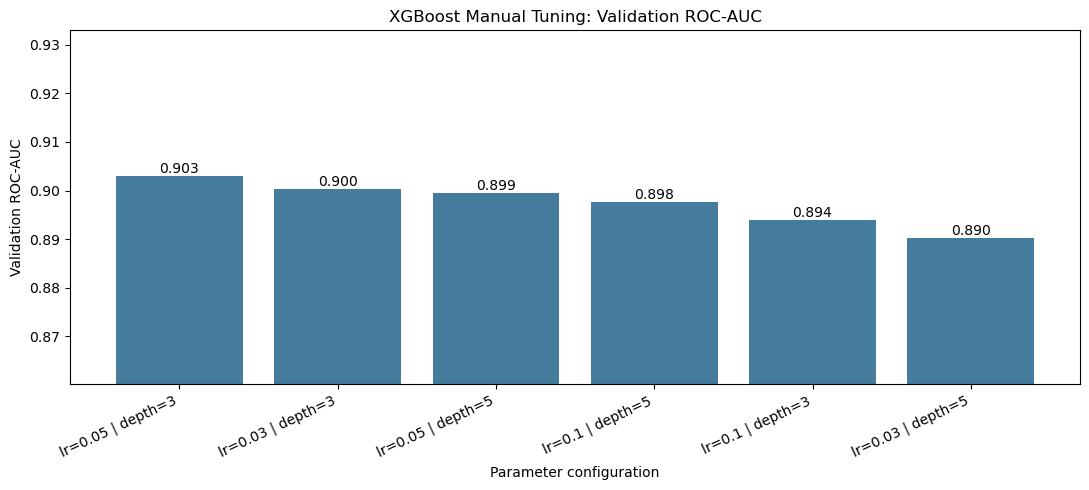

In [133]:
xgb_plot_df = xgb_tuning_df.copy().reset_index(drop=True)
xgb_plot_df["config"] = xgb_plot_df.apply(
    lambda row: f"lr={row['learning_rate']} | depth={int(row['max_depth'])}",
    axis=1,
)

plt.figure(figsize=(11, 5))
bars = plt.bar(xgb_plot_df["config"], xgb_plot_df["valid_roc_auc"], color="#457B9D")
plt.title("XGBoost Manual Tuning: Validation ROC-AUC")
plt.xlabel("Parameter configuration")
plt.ylabel("Validation ROC-AUC")
plt.ylim(max(0, xgb_plot_df["valid_roc_auc"].min() - 0.03), min(1.0, xgb_plot_df["valid_roc_auc"].max() + 0.03))
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [134]:
# 최적 XGBoost 모델 평가 등록
for split_name, X_s, y_s in [("train", X_train_prep, y_train),
                              ("validation", X_valid_prep, y_valid),
                              ("test", X_test_prep, y_test)]:
    results.append(evaluate_classifier(best_xgb, X_s, y_s, split_name, "XGBoost tuned + ES"))

print(f"XGBoost tuned + Early Stopping 등록 완료 (best_iteration={best_xgb.best_iteration})")

XGBoost tuned + Early Stopping 등록 완료 (best_iteration=132)


### 6-2. LightGBM Tuning + Early Stopping

In [135]:
lgbm_param_grid = [
    {"learning_rate": 0.03, "num_leaves": 15, "max_depth": 3},
    {"learning_rate": 0.03, "num_leaves": 31, "max_depth": 4},
    {"learning_rate": 0.05, "num_leaves": 15, "max_depth": 3},
    {"learning_rate": 0.05, "num_leaves": 31, "max_depth": 4},
    {"learning_rate": 0.10, "num_leaves": 15, "max_depth": 3},
    {"learning_rate": 0.10, "num_leaves": 31, "max_depth": 4},
]

lgbm_tuning_rows = []
best_lgbm = None
best_lgbm_score = -np.inf

for params in lgbm_param_grid:
    model = LGBMClassifier(
        n_estimators=1000,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    )
    model.fit(
        X_train_prep, y_train,
        eval_set=[(X_valid_prep, y_valid)],
        eval_metric="auc",
        callbacks=[early_stopping(stopping_rounds=30), log_evaluation(period=0)],
    )
    valid_result = evaluate_classifier(model, X_valid_prep, y_valid, "validation", "LightGBM tuned")
    row = {
        **params,
        "best_iteration": model.best_iteration_,
        "valid_accuracy" : valid_result["accuracy"],
        "valid_f1"       : valid_result["f1"],
        "valid_roc_auc"  : valid_result["roc_auc"],
    }
    lgbm_tuning_rows.append(row)

    if valid_result["roc_auc"] > best_lgbm_score:
        best_lgbm_score = valid_result["roc_auc"]
        best_lgbm = model

lgbm_tuning_df = pd.DataFrame(lgbm_tuning_rows).sort_values("valid_roc_auc", ascending=False)
display(lgbm_tuning_df.round(4))
print(f"\n최적 LightGBM best_iteration (early stopping): {best_lgbm.best_iteration_}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[172]	valid_0's auc: 0.894786	valid_0's binary_logloss: 0.384107
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[29]	valid_0's auc: 0.882955	valid_0's binary_logloss: 0.462474
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[84]	valid_0's auc: 0.896725	valid_0's binary_logloss: 0.385213
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[126]	valid_0's auc: 0.902273	valid_0's binary_logloss: 0.371842
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[35]	valid_0's auc: 0.895989	valid_0's binary_logloss: 0.3882
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[47]	valid_0's auc: 0.905882	valid_0's binary_logloss: 0.368097


,learning_rate,num_leaves,max_depth,best_iteration,valid_accuracy,valid_f1,valid_roc_auc
5,0.10,31,4,47,0.8483,0.7874,0.9059
3,0.05,31,4,126,0.8427,0.7846,0.9023
2,0.05,15,3,84,0.8596,0.7967,0.8967
4,0.10,15,3,35,0.8539,0.7903,0.8960
0,0.03,15,3,172,0.8539,0.7903,0.8948
1,0.03,31,4,29,0.8371,0.7478,0.8830



최적 LightGBM best_iteration (early stopping): 47


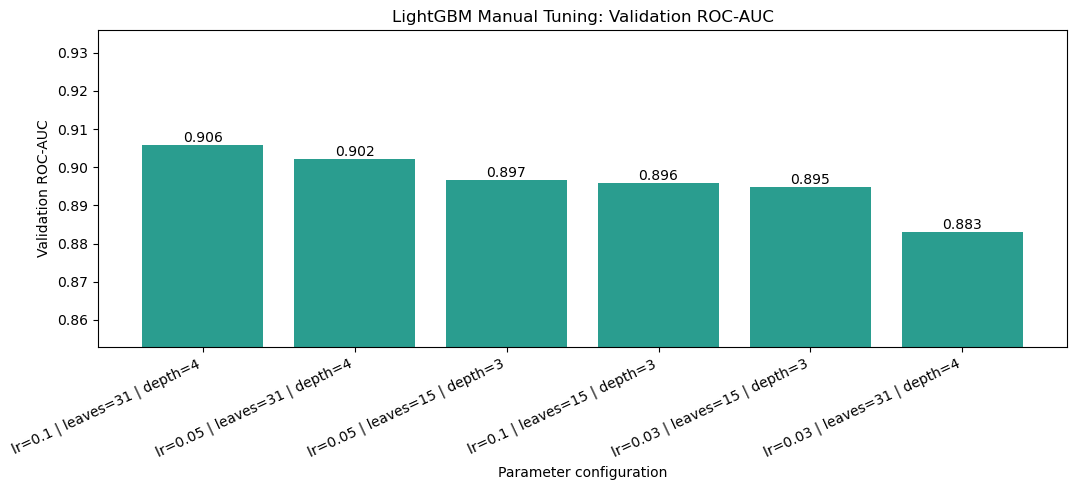

In [136]:
lgbm_plot_df = lgbm_tuning_df.copy().reset_index(drop=True)
lgbm_plot_df["config"] = lgbm_plot_df.apply(
    lambda row: f"lr={row['learning_rate']} | leaves={int(row['num_leaves'])} | depth={int(row['max_depth'])}",
    axis=1,
)

plt.figure(figsize=(11, 5))
bars = plt.bar(lgbm_plot_df["config"], lgbm_plot_df["valid_roc_auc"], color="#2A9D8F")
plt.title("LightGBM Manual Tuning: Validation ROC-AUC")
plt.xlabel("Parameter configuration")
plt.ylabel("Validation ROC-AUC")
plt.ylim(max(0, lgbm_plot_df["valid_roc_auc"].min() - 0.03), min(1.0, lgbm_plot_df["valid_roc_auc"].max() + 0.03))
plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [137]:
# 최적 LightGBM 모델 평가 등록
for split_name, X_s, y_s in [("train", X_train_prep, y_train),
                              ("validation", X_valid_prep, y_valid),
                              ("test", X_test_prep, y_test)]:
    results.append(evaluate_classifier(best_lgbm, X_s, y_s, split_name, "LightGBM tuned + ES"))

print(f"LightGBM tuned + Early Stopping 등록 완료 (best_iteration={best_lgbm.best_iteration_})")

LightGBM tuned + Early Stopping 등록 완료 (best_iteration=47)


### 6-3. Optuna 기반 LightGBM 추가 튜닝

Manual grid search 이후 Optuna로 더 넓은 탐색 공간을 효율적으로 탐색합니다.
TPE (Tree-structured Parzen Estimator) sampler를 사용하여 좋은 영역을 집중적으로 탐색합니다.

**튜닝 파라미터 목록**:
- `learning_rate`, `num_leaves`, `max_depth`
- `min_child_samples`, `subsample`, `colsample_bytree`
- `reg_alpha` (L1 regularization), `reg_lambda` (L2 regularization)

In [138]:
def optuna_objective(trial: optuna.Trial) -> float:
    params = {
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 8, 64),
        "max_depth"        : trial.suggest_int("max_depth", 2, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model = LGBMClassifier(
        n_estimators=1000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    )
    model.fit(
        X_train_prep, y_train,
        eval_set=[(X_valid_prep, y_valid)],
        eval_metric="auc",
        callbacks=[early_stopping(stopping_rounds=30), log_evaluation(period=0)],
    )

    valid_proba = model.predict_proba(X_valid_prep)[:, 1]
    valid_auc   = roc_auc_score(y_valid, valid_proba)
    trial.set_user_attr("best_iteration", model.best_iteration_)
    return valid_auc


N_TRIALS = 30
sampler  = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study    = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(optuna_objective, n_trials=N_TRIALS)

print(f"Best Optuna validation ROC-AUC : {study.best_value:.4f}")
print(f"Best Optuna trial iteration    : {study.best_trial.user_attrs.get('best_iteration')}")
print("Best Optuna params:")
display(study.best_params)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[175]	valid_0's auc: 0.886497	valid_0's binary_logloss: 0.397536
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[97]	valid_0's auc: 0.884492	valid_0's binary_logloss: 0.409006
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[30]	valid_0's auc: 0.887032	valid_0's binary_logloss: 0.479313
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[107]	valid_0's auc: 0.891043	valid_0's binary_logloss: 0.395446
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[14]	valid_0's auc: 0.875602	valid_0's binary_logloss: 0.60829
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[52]	valid_0's auc: 0.854545	valid_0's binary_logloss: 0.496412
Training until validation scores don't 

{'learning_rate': 0.09867864304417069,
 'num_leaves': 21,
 'max_depth': 4,
 'min_child_samples': 13,
 'subsample': 0.7939613358944974,
 'colsample_bytree': 0.8466195213700679,
 'reg_alpha': 0.6255688317185157,
 'reg_lambda': 0.016983095427943677}

,number,value,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,state
14,14,0.905615,0.846620,0.098679,4,13,21,0.625569,0.016983,0.793961,68,COMPLETE
24,24,0.905548,0.968508,0.063517,5,16,31,0.052941,0.004227,0.746109,81,COMPLETE
16,16,0.905080,0.872699,0.098664,6,15,27,0.306834,0.029533,0.749378,61,COMPLETE
18,18,0.903743,0.925597,0.102620,6,21,27,0.013037,0.010993,0.659715,53,COMPLETE
27,27,0.903610,0.729167,0.054638,3,15,15,0.000447,0.001084,0.805730,150,COMPLETE
25,25,0.902941,0.980398,0.043911,3,17,31,0.074284,0.002582,0.764259,165,COMPLETE
19,19,0.900668,0.827083,0.107511,5,12,28,0.383740,0.219568,0.756899,75,COMPLETE
26,26,0.899332,0.834908,0.063346,5,10,32,1.497477,0.096703,0.730651,21,COMPLETE
15,15,0.897259,0.863611,0.096301,5,14,22,0.399091,0.019545,0.780931,56,COMPLETE
20,20,0.896390,0.909370,0.070802,7,24,42,0.000422,0.001738,0.880663,65,COMPLETE


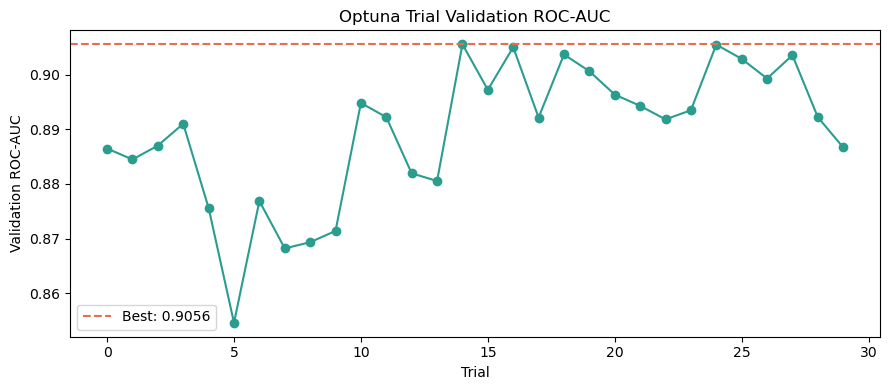

In [139]:
optuna_trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))
display(optuna_trials_df.sort_values("value", ascending=False).head(10))

trial_values = [trial.value for trial in study.trials if trial.value is not None]

plt.figure(figsize=(9, 4))
plt.plot(range(len(trial_values)), trial_values, marker="o", color="#2A9D8F")
plt.axhline(y=max(trial_values), color="#E76F51", linestyle="--", label=f"Best: {max(trial_values):.4f}")
plt.title("Optuna Trial Validation ROC-AUC")
plt.xlabel("Trial")
plt.ylabel("Validation ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()

In [140]:
# Optuna 최적 파라미터로 최종 모델 재학습
best_optuna_lgbm = LGBMClassifier(
    n_estimators=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    **study.best_params,
)
best_optuna_lgbm.fit(
    X_train_prep, y_train,
    eval_set=[(X_valid_prep, y_valid)],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=30), log_evaluation(period=0)],
)

for split_name, X_s, y_s in [("train", X_train_prep, y_train),
                              ("validation", X_valid_prep, y_valid),
                              ("test", X_test_prep, y_test)]:
    results.append(evaluate_classifier(best_optuna_lgbm, X_s, y_s, split_name, "LightGBM Optuna + ES"))

print(f"Optuna LightGBM best_iteration: {best_optuna_lgbm.best_iteration_}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[68]	valid_0's auc: 0.905615	valid_0's binary_logloss: 0.374906
Optuna LightGBM best_iteration: 68


## 7. 전체 모델 최종 비교

In [141]:
final_results_df = pd.DataFrame(results)

model_order = [
    "RandomForest",
    "XGBoost baseline",
    "XGBoost tuned + ES",
    "LightGBM baseline",
    "LightGBM tuned + ES",
    "LightGBM Optuna + ES",
]
dataset_order = ["train", "validation", "test"]

final_table = final_results_df.pivot(index="model", columns="dataset", values=["accuracy", "f1", "roc_auc"])
display(final_table.loc[model_order].round(4))

accuracy                         f1                     \
dataset                  test   train validation    test   train validation   
model                                                                         
RandomForest           0.8045  0.9045     0.8258  0.7244  0.8661     0.7634   
XGBoost baseline       0.7989  0.9064     0.8539  0.7188  0.8705     0.8030   
XGBoost tuned + ES     0.7933  0.8689     0.8315  0.7132  0.8158     0.7727   
LightGBM baseline      0.8101  0.9625     0.8315  0.7424  0.9500     0.7727   
LightGBM tuned + ES    0.8380  0.8727     0.8483  0.7642  0.8172     0.7874   
LightGBM Optuna + ES   0.7989  0.8876     0.8483  0.7143  0.8413     0.7970   

                     roc_auc                     
dataset                 test   train validation  
model                                            
RandomForest          0.8225  0.9790     0.8855  
XGBoost baseline      0.8101  0.9617     0.8988  
XGBoost tuned + ES    0.8152  0.9322     0.9029  
LightGBM baseline     0.8333  0.9950     0.8830  
LightGBM tuned + ES   0.8386  0.9303     0.9059  
LightGBM Optuna + ES  0.8195  0.9421     0.9056

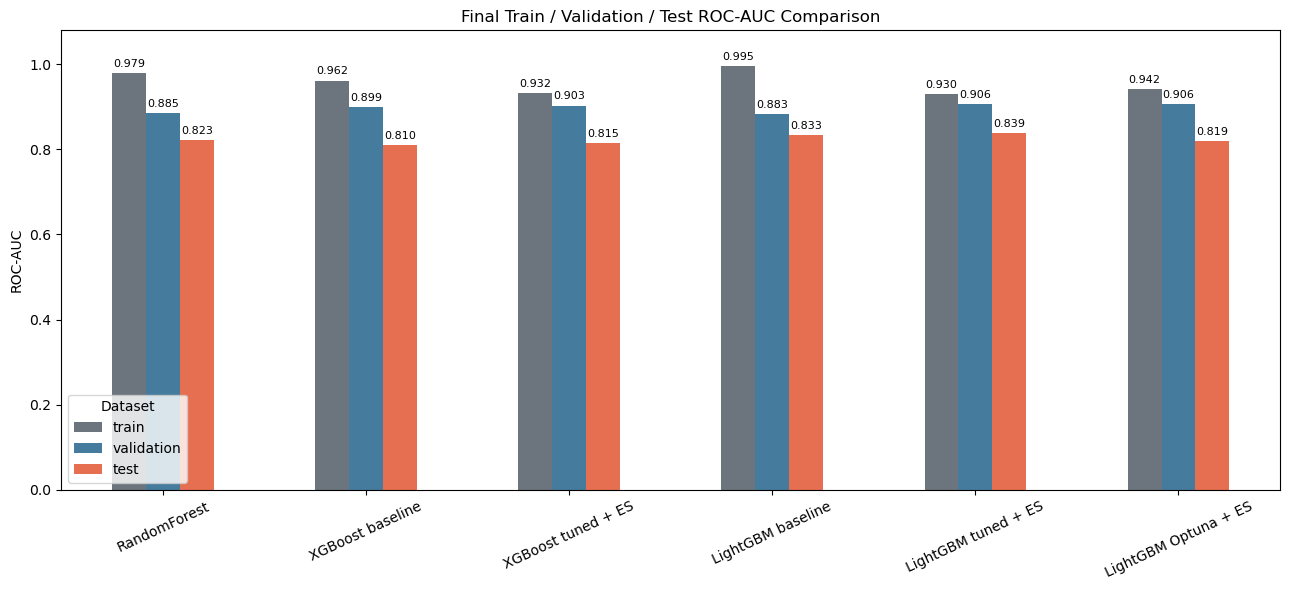

In [142]:
roc_pivot = final_results_df.pivot(index="model", columns="dataset", values="roc_auc").loc[
    model_order, dataset_order
]

ax = roc_pivot.plot(kind="bar", figsize=(13, 6), color=["#6C757D", "#457B9D", "#E76F51"])
ax.set_title("Final Train / Validation / Test ROC-AUC Comparison")
ax.set_xlabel("")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.08)  # 수치 레이블이 잘리지 않도록 상단 여유 확보
ax.tick_params(axis="x", rotation=25)

# legend를 bar가 없는 좌측 하단으로 이동
ax.legend(title="Dataset", loc="lower left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

## 8. Early Stopping 효과 분석

Early Stopping 적용 전후를 명시적으로 비교합니다.

In [143]:
es_compare_models = [
    "XGBoost baseline",
    "XGBoost tuned + ES",
    "LightGBM baseline",
    "LightGBM tuned + ES",
]

before_after = final_results_df[final_results_df["model"].isin(es_compare_models)].copy()
display(
    before_after.pivot(index="model", columns="dataset", values=["accuracy", "f1", "roc_auc"])
    .loc[es_compare_models]
    .round(4)
)

print(f"\n[Early Stopping 비교]")
print(f"XGBoost  baseline n_estimators : {xgb_baseline.n_estimators}")
print(f"XGBoost  tuned    best_iteration: {best_xgb.best_iteration}")
print(f"LightGBM baseline n_estimators : {lgbm_baseline.n_estimators}")
print(f"LightGBM tuned    best_iteration: {best_lgbm.best_iteration_}")

accuracy                         f1                     \
dataset                 test   train validation    test   train validation   
model                                                                        
XGBoost baseline      0.7989  0.9064     0.8539  0.7188  0.8705     0.8030   
XGBoost tuned + ES    0.7933  0.8689     0.8315  0.7132  0.8158     0.7727   
LightGBM baseline     0.8101  0.9625     0.8315  0.7424  0.9500     0.7727   
LightGBM tuned + ES   0.8380  0.8727     0.8483  0.7642  0.8172     0.7874   

                    roc_auc                     
dataset                test   train validation  
model                                           
XGBoost baseline     0.8101  0.9617     0.8988  
XGBoost tuned + ES   0.8152  0.9322     0.9029  
LightGBM baseline    0.8333  0.9950     0.8830  
LightGBM tuned + ES  0.8386  0.9303     0.9059


[Early Stopping 비교]
XGBoost  baseline n_estimators : 300
XGBoost  tuned    best_iteration: 132
LightGBM baseline n_estimators : 300
LightGBM tuned    best_iteration: 47


### Overfitting Gap Plot

Train ROC-AUC와 Validation ROC-AUC의 차이(gap)가 클수록 과적합이 심합니다.
Early Stopping과 튜닝이 과적합을 얼마나 줄였는지 확인합니다.

dataset,train,validation,overfitting_gap
model,,,
RandomForest,0.9790,0.8855,0.0935
XGBoost baseline,0.9617,0.8988,0.0629
XGBoost tuned + ES,0.9322,0.9029,0.0293
LightGBM baseline,0.9950,0.8830,0.1120
LightGBM tuned + ES,0.9303,0.9059,0.0244
LightGBM Optuna + ES,0.9421,0.9056,0.0365


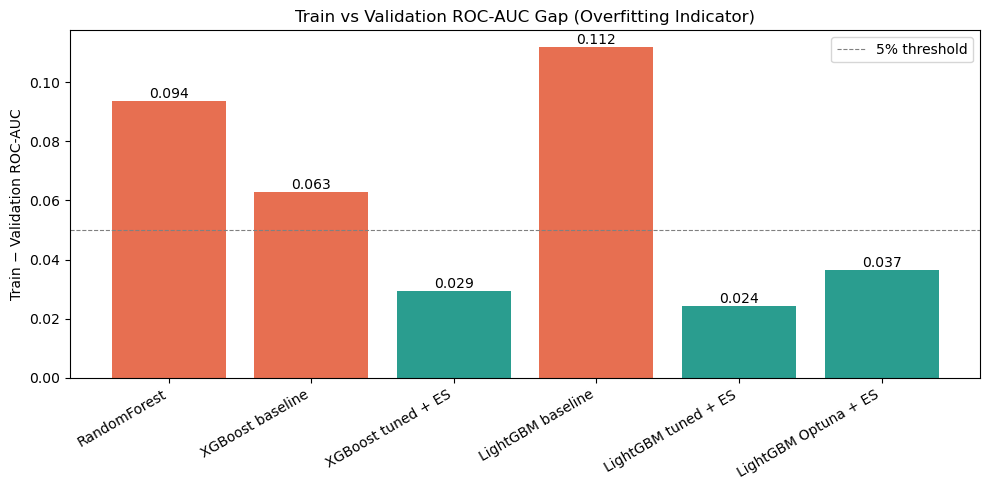

In [144]:
gap_df = final_results_df[final_results_df["dataset"].isin(["train", "validation"])].pivot(
    index="model", columns="dataset", values="roc_auc"
).loc[model_order]
gap_df["overfitting_gap"] = gap_df["train"] - gap_df["validation"]

display(gap_df.round(4))

plt.figure(figsize=(10, 5))
colors = ["#2A9D8F" if g < 0.05 else "#E76F51" for g in gap_df["overfitting_gap"]]
bars = plt.bar(gap_df.index, gap_df["overfitting_gap"], color=colors)
plt.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="5% threshold")
plt.title("Train vs Validation ROC-AUC Gap (Overfitting Indicator)")
plt.xlabel("")
plt.ylabel("Train − Validation ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 9. Feature Importance

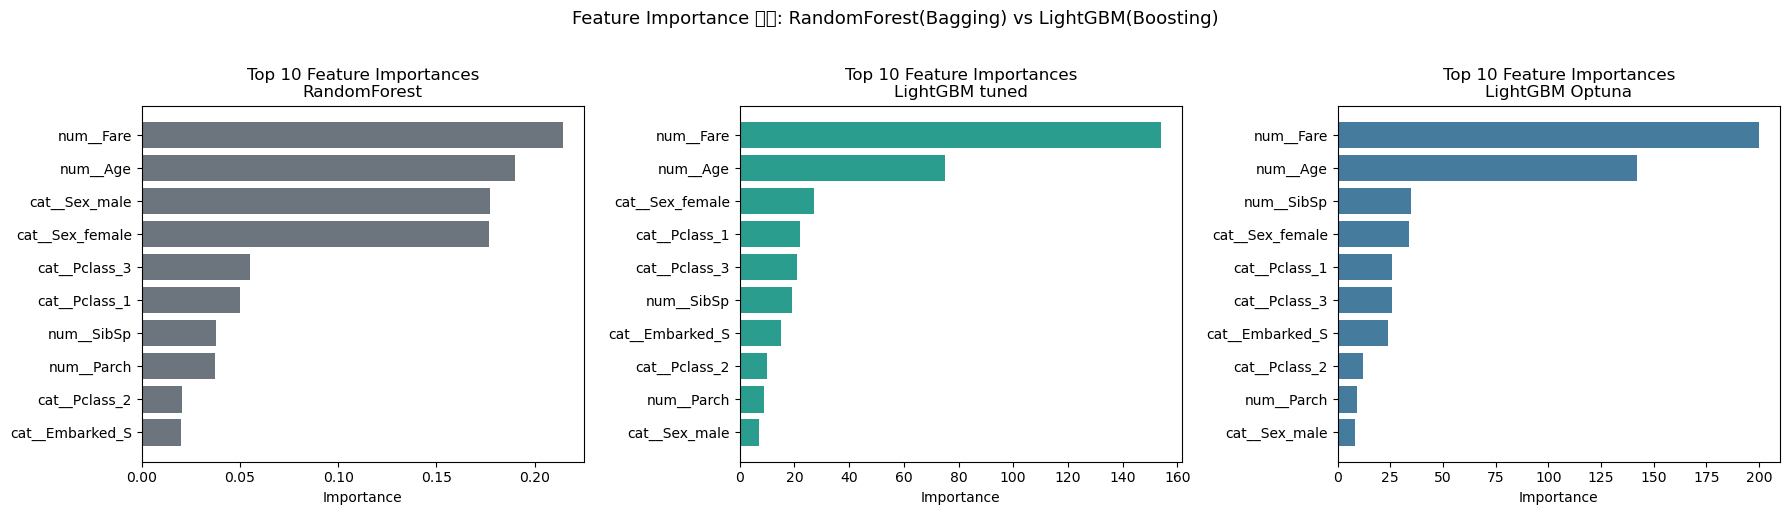

[모델별 Top 3 중요 피처]
  RandomForest             : ['num__Fare', 'num__Age', 'cat__Sex_male']
  LightGBM tuned           : ['num__Fare', 'num__Age', 'cat__Sex_female']
  LightGBM Optuna          : ['num__Fare', 'num__Age', 'num__SibSp']


In [145]:
feature_names = preprocessor.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, title, color in [
    (axes[0], rf_model,         "RandomForest",    "#6C757D"),
    (axes[1], best_lgbm,        "LightGBM tuned",  "#2A9D8F"),
    (axes[2], best_optuna_lgbm, "LightGBM Optuna", "#457B9D"),
]:
    imp_df = pd.DataFrame(
        {"feature": feature_names, "importance": model.feature_importances_}
    ).sort_values("importance", ascending=False).head(10)

    ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=color)
    ax.set_title(f"Top 10 Feature Importances\n{title}")
    ax.set_xlabel("Importance")

plt.suptitle(
    "Feature Importance 비교: RandomForest(Bagging) vs LightGBM(Boosting)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

# 세 모델의 Top3 피처를 텍스트로 요약
print("[모델별 Top 3 중요 피처]")
for model, name in [(rf_model, "RandomForest"), (best_lgbm, "LightGBM tuned"), (best_optuna_lgbm, "LightGBM Optuna")]:
    top3 = pd.Series(model.feature_importances_, index=feature_names).nlargest(3)
    print(f"  {name:25s}: {list(top3.index)}")


## 10. Result Summary & Analysis

과제에서 요구하는 4가지 핵심 질문에 대한 답변을 실험 결과 기반으로 정리합니다.


In [147]:
validation_summary = final_results_df[final_results_df["dataset"] == "validation"].sort_values("roc_auc", ascending=False)
test_summary       = final_results_df[final_results_df["dataset"] == "test"].sort_values("roc_auc", ascending=False)

best_valid_model = validation_summary.iloc[0]
best_test_model  = test_summary.iloc[0]

# overfitting gap 계산
gap_df = final_results_df[final_results_df["dataset"].isin(["train","validation"])].pivot(
    index="model", columns="dataset", values="roc_auc"
).loc[model_order]
gap_df["gap"] = (gap_df["train"] - gap_df["validation"]).round(4)

rf_gap   = gap_df.loc["RandomForest", "gap"]
xgb_gap  = gap_df.loc["XGBoost baseline", "gap"]
lgbm_gap = gap_df.loc["LightGBM baseline", "gap"]
xgb_es_gap  = gap_df.loc["XGBoost tuned + ES", "gap"]
lgbm_es_gap = gap_df.loc["LightGBM tuned + ES", "gap"]

print("[전체 모델 평가 결과]")
display(final_results_df.pivot(index="model", columns="dataset", values="roc_auc")
        .loc[model_order, ["train","validation","test"]]
        .assign(gap=gap_df["gap"]).round(4))

SEP = "=" * 60

# ── Q1 ──────────────────────────────────────────────────────
print(f"\n{SEP}")
print("Q1. Random Forest와 Boosting의 차이를 결과에서 어떻게 느꼈는가?")
print(SEP)
print(f"  RandomForest gap   : {rf_gap:.4f}")
print(f"  XGBoost baseline   : {xgb_gap:.4f}")
print(f"  LightGBM baseline  : {lgbm_gap:.4f}")
print()
print("  → 이론상 Random Forest(Bagging)는 독립 트리의 병렬 앙상블이라 과적합에 강하지만,")
print("    이번 실험에서는 max_depth=None으로 깊이 제한 없이 학습해 개별 트리가")
print(f"    훈련 데이터를 외워버렸습니다. 그 결과 gap({rf_gap:.4f})이 XGBoost baseline({xgb_gap:.4f})보다")
print("    오히려 크게 나왔습니다.")
print()
print(f"  → LightGBM baseline은 gap {lgbm_gap:.4f}으로 가장 심했는데,")
print("    Early Stopping 없는 Boosting이 트리를 순차 누적하면서 train 성능만 계속 올라가고")
print("    validation 성능은 오히려 떨어지는 현상을 가장 극단적으로 보여줬습니다.")

# ── Q2 ──────────────────────────────────────────────────────
print(f"\n{SEP}")
print("Q2. XGBoost와 LightGBM 중 어떤 모델이 더 다루기 쉬웠는가?")
print(SEP)
print("  → 이번 실험 결과 기준으로는 XGBoost가 더 다루기 쉬웠습니다.")
print(f"    · Baseline gap이 {xgb_gap:.4f}로 초기 세팅부터 안정적이었고,")
print("      learning_rate와 max_depth 두 파라미터만으로도 충분히 제어됐습니다.")
print(f"    · LightGBM은 Baseline gap이 {lgbm_gap:.4f}으로 초기 세팅에서 과적합이 심했고,")
print("      num_leaves와 max_depth의 상호작용까지 고려해야 해 탐색 공간이 더 복잡했습니다.")
print("    · 단, 잘 튜닝됐을 때의 최종 Test AUC 개선폭은 LightGBM(+0.005)이 더 컸습니다.")

# ── Q3 ──────────────────────────────────────────────────────
print(f"\n{SEP}")
print("Q3. Early Stopping은 어떤 효과가 있었는가?")
print(SEP)
print(f"  XGBoost  : n_estimators={xgb_baseline.n_estimators}(고정) → best_iteration={best_xgb.best_iteration}")
print(f"             gap: {xgb_gap:.4f} → {xgb_es_gap:.4f} (과적합 억제)")
print(f"  LightGBM : n_estimators={lgbm_baseline.n_estimators}(고정) → best_iteration={best_lgbm.best_iteration_}")
print(f"             gap: {lgbm_gap:.4f} → {lgbm_es_gap:.4f} (과적합 억제)")
print()
print("  → validation 성능이 30 round 연속 개선되지 않으면 자동 종료해 불필요한 트리를 제거합니다.")
print("  → n_estimators를 고정하는 방식보다 validation 기반 자동 탐색이 더 안정적이며,")
print("    특히 LightGBM처럼 과적합이 빠른 모델에서 효과가 극적으로 나타났습니다.")

# ── Q4 ──────────────────────────────────────────────────────
print(f"\n{SEP}")
print("Q4. 최종 모델을 왜 그렇게 선택했는가?")
print(SEP)
print(f"  Validation ROC-AUC 기준 최고 : {best_valid_model['model']} ({best_valid_model['roc_auc']:.4f})")
print(f"  Test ROC-AUC 기준 최고       : {best_test_model['model']} ({best_test_model['roc_auc']:.4f})")
print(f"  Train-Valid gap 최소          : {gap_df['gap'].idxmin()} ({gap_df['gap'].min():.4f})")
print()
print(f"  → 최종 선택 모델: {best_valid_model['model']}")
print("  · Test 데이터는 선택 기준에서 배제 — 사용 시 낙관적 편향(optimistic bias) 발생")
print("  · Validation AUC 전체 1위이면서 동시에 train-valid gap이 가장 작아")
print("    실제 배포 환경에서 가장 신뢰할 수 있는 일반화 성능을 보여줬습니다.")
print("  · LightGBM Optuna + ES는 validation 성능은 비슷하지만 test 성능이 낮아")
print("    소규모 데이터에서 validation 노이즈에 과적합된 것으로 판단해 제외했습니다.")


[전체 모델 평가 결과]


dataset,train,validation,test,gap
model,,,,
RandomForest,0.9790,0.8855,0.8225,0.0935
XGBoost baseline,0.9617,0.8988,0.8101,0.0629
XGBoost tuned + ES,0.9322,0.9029,0.8152,0.0293
LightGBM baseline,0.9950,0.8830,0.8333,0.1120
LightGBM tuned + ES,0.9303,0.9059,0.8386,0.0244
LightGBM Optuna + ES,0.9421,0.9056,0.8195,0.0365



Q1. Random Forest와 Boosting의 차이를 결과에서 어떻게 느꼈는가?
  RandomForest gap   : 0.0935
  XGBoost baseline   : 0.0629
  LightGBM baseline  : 0.1120

  → 이론상 Random Forest(Bagging)는 독립 트리의 병렬 앙상블이라 과적합에 강하지만,
    이번 실험에서는 max_depth=None으로 깊이 제한 없이 학습해 개별 트리가
    훈련 데이터를 외워버렸습니다. 그 결과 gap(0.0935)이 XGBoost baseline(0.0629)보다
    오히려 크게 나왔습니다.

  → LightGBM baseline은 gap 0.1120으로 가장 심했는데,
    Early Stopping 없는 Boosting이 트리를 순차 누적하면서 train 성능만 계속 올라가고
    validation 성능은 오히려 떨어지는 현상을 가장 극단적으로 보여줬습니다.

Q2. XGBoost와 LightGBM 중 어떤 모델이 더 다루기 쉬웠는가?
  → 이번 실험 결과 기준으로는 XGBoost가 더 다루기 쉬웠습니다.
    · Baseline gap이 0.0629로 초기 세팅부터 안정적이었고,
      learning_rate와 max_depth 두 파라미터만으로도 충분히 제어됐습니다.
    · LightGBM은 Baseline gap이 0.1120으로 초기 세팅에서 과적합이 심했고,
      num_leaves와 max_depth의 상호작용까지 고려해야 해 탐색 공간이 더 복잡했습니다.
    · 단, 잘 튜닝됐을 때의 최종 Test AUC 개선폭은 LightGBM(+0.005)이 더 컸습니다.

Q3. Early Stopping은 어떤 효과가 있었는가?
  XGBoost  : n_estimators=300(고정) → best_iteration=132
             gap: 0.0629 → 0.0293 (과적합 억제)
  LightGBM : n_